<a href="https://colab.research.google.com/github/Bhanulion143/Stock-Price-Predictor/blob/main/notebooks/stock_predictor_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
!pip install yfinance tensorflow scikit-learn -q

In [22]:
# ✅ Run this first — install dependencies
!pip install yfinance tensorflow scikit-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("✅ All libraries loaded!")

✅ All libraries loaded!


In [23]:
TICKER = 'AAPL'
stock = yf.Ticker(TICKER)
df = stock.history(period='2y')
df.index = df.index.tz_localize(None)
close = df['Close'].values

print(f'Loaded {len(close)} days of {TICKER} closing prices')
print(f'Date range: {df.index[0].date()} to {df.index[-1].date()}')
print(f'Price range: ${close.min():.2f} - ${close.max():.2f}')
df[['Close']].tail()

Loaded 501 days of AAPL closing prices
Date range: 2024-06-04 to 2026-06-03
Price range: $171.51 - $315.20


,Close
Date,
2026-05-28,312.510010
2026-05-29,312.059998
2026-06-01,306.309998
2026-06-02,315.200012
2026-06-03,310.260010


## 2. Visualize Raw Data

✅ RMSE: 3.83 | R² Score: 0.9802


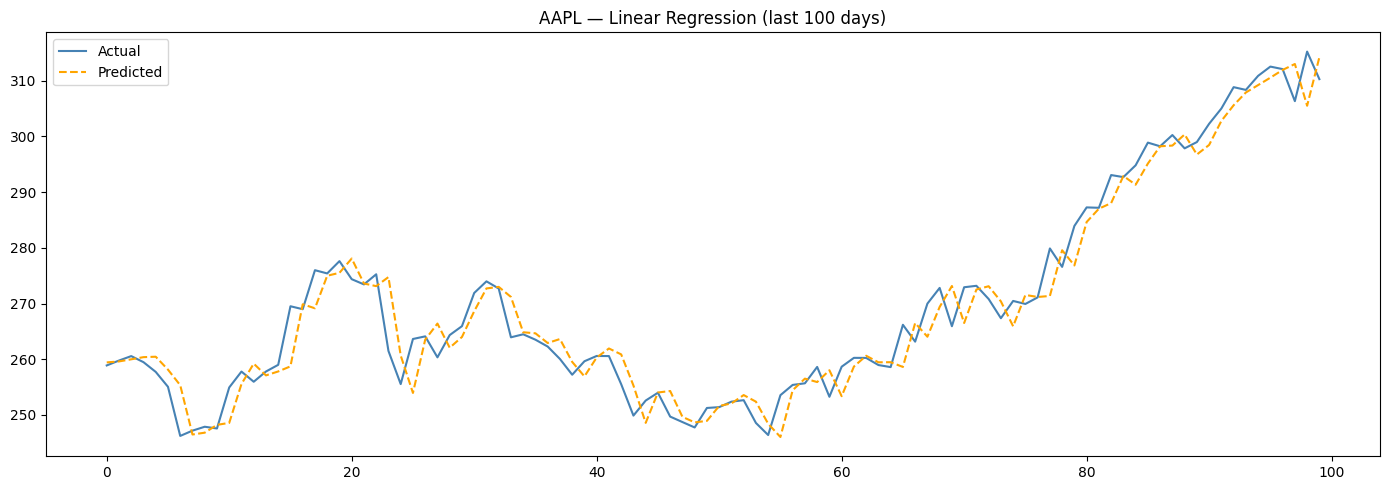

In [24]:
# Linear Regression prediction
LOOKBACK = 30
scaler = MinMaxScaler()
scaled = scaler.fit_transform(close.reshape(-1,1))

X, y = [], []
for i in range(LOOKBACK, len(scaled)):
    X.append(scaled[i-LOOKBACK:i, 0])
    y.append(scaled[i, 0])
X, y = np.array(X), np.array(y)

model = LinearRegression()
model.fit(X, y)
preds = scaler.inverse_transform(model.predict(X).reshape(-1,1)).flatten()
actual = close[LOOKBACK:]

rmse = np.sqrt(mean_squared_error(actual, preds))
r2 = r2_score(actual, preds)
print(f"✅ RMSE: {rmse:.2f} | R² Score: {r2:.4f}")

plt.figure(figsize=(14,5))
plt.plot(actual[-100:], label='Actual', color='steelblue')
plt.plot(preds[-100:], label='Predicted', color='orange', linestyle='--')
plt.title(f'{TICKER} — Linear Regression (last 100 days)')
plt.legend()
plt.tight_layout()
plt.show()

## 3. Train Linear Regression Model

In [25]:
plt.tight_layout()
plt.show()  # ✅ keep only this

<Figure size 640x480 with 0 Axes>

In [26]:
# ✅ Linear Regression Model (no imports needed)
LOOKBACK = 30

scaler_lr = MinMaxScaler(feature_range=(0, 1))
scaled = scaler_lr.fit_transform(close.reshape(-1, 1))

# Create sequences
X, y = [], []
for i in range(LOOKBACK, len(scaled)):
    X.append(scaled[i-LOOKBACK:i, 0])
    y.append(scaled[i, 0])
X, y = np.array(X), np.array(y)

# Train
lr = LinearRegression()
lr.fit(X, y)

# Historical predictions
lr_preds = scaler_lr.inverse_transform(lr.predict(X).reshape(-1,1)).flatten()
actual_for_eval = close[LOOKBACK:]

# Future 30-day forecast
window = list(scaled[-LOOKBACK:].flatten())
lr_future = []
for _ in range(30):
    x_in = np.array(window[-LOOKBACK:]).reshape(1, -1)
    nxt = lr.predict(x_in)[0]
    window.append(nxt)
    lr_future.append(nxt)
lr_future = scaler_lr.inverse_transform(np.array(lr_future).reshape(-1,1)).flatten()

# Metrics
rmse = np.sqrt(mean_squared_error(actual_for_eval, lr_preds))
mae  = mean_absolute_error(actual_for_eval, lr_preds)
r2   = r2_score(actual_for_eval, lr_preds)
mape = np.mean(np.abs((actual_for_eval - lr_preds) / actual_for_eval)) * 100

print("✅ Linear Regression trained!")
print(f"   RMSE     : {rmse:.2f}")
print(f"   MAE      : {mae:.2f}")
print(f"   R² Score : {r2:.4f}")
print(f"   MAPE     : {mape:.2f}%")

✅ Linear Regression trained!
   RMSE     : 3.83
   MAE      : 2.66
   R² Score : 0.9802
   MAPE     : 1.14%


## 4. Train LSTM Model

In [27]:
# ✅ LSTM Model (no imports needed)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

LOOKBACK_LSTM = 60

scaler_lstm = MinMaxScaler(feature_range=(0, 1))
scaled_lstm = scaler_lstm.fit_transform(close.reshape(-1, 1))

# Create sequences
X2, y2 = [], []
for i in range(LOOKBACK_LSTM, len(scaled_lstm)):
    X2.append(scaled_lstm[i-LOOKBACK_LSTM:i, 0])
    y2.append(scaled_lstm[i, 0])
X2 = np.array(X2).reshape(-1, LOOKBACK_LSTM, 1)
y2 = np.array(y2)

# Build & train
lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(LOOKBACK_LSTM, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mean_squared_error')
lstm_model.fit(X2, y2, epochs=20, batch_size=32, verbose=1, validation_split=0.1)

# Historical predictions
lstm_preds = scaler_lstm.inverse_transform(lstm_model.predict(X2)).flatten()
actual_for_eval_lstm = close[LOOKBACK_LSTM:]

# Future 30-day forecast
window2 = list(scaled_lstm[-LOOKBACK_LSTM:].flatten())
lstm_future = []
for _ in range(30):
    x_in = np.array(window2[-LOOKBACK_LSTM:]).reshape(1, LOOKBACK_LSTM, 1)
    nxt = lstm_model.predict(x_in, verbose=0)[0][0]
    window2.append(nxt)
    lstm_future.append(nxt)
lstm_future = scaler_lstm.inverse_transform(np.array(lstm_future).reshape(-1,1)).flatten()

# Metrics
rmse2 = np.sqrt(mean_squared_error(actual_for_eval_lstm, lstm_preds))
mae2  = mean_absolute_error(actual_for_eval_lstm, lstm_preds)
r2_2  = r2_score(actual_for_eval_lstm, lstm_preds)
mape2 = np.mean(np.abs((actual_for_eval_lstm - lstm_preds) / actual_for_eval_lstm)) * 100

print("✅ LSTM trained!")
print(f"   RMSE     : {rmse2:.2f}")
print(f"   MAE      : {mae2:.2f}")
print(f"   R² Score : {r2_2:.4f}")
print(f"   MAPE     : {mape2:.2f}%")

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 239ms/step - loss: 0.0685 - val_loss: 0.0322
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 164ms/step - loss: 0.0139 - val_loss: 0.0152
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - loss: 0.0089 - val_loss: 0.0288
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.0068 - val_loss: 0.0131
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0056 - val_loss: 0.0179
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0055 - val_loss: 0.0069
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0062 - val_loss: 0.0061
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0053 - val_loss: 0.0098
Epoch 9/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0054 - val_loss: 0.0120
Epoch 10/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0055 - val_loss: 0.0114
Epoch 11/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0058 - val_loss: 0.0039
Epoch 12/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss

## 5. Compare Predictions vs Actual

✅ Done!


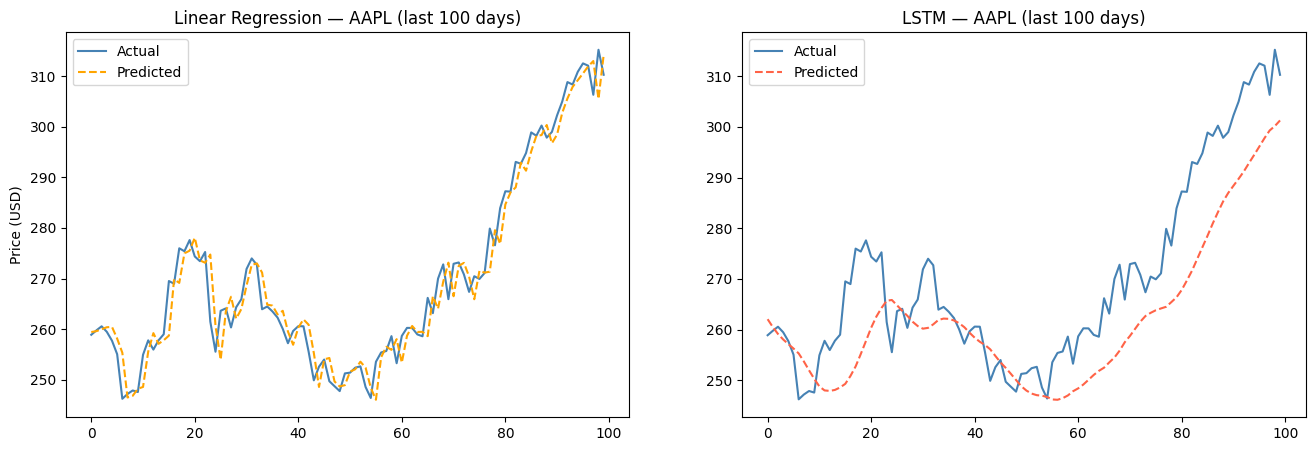

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Linear Regression
axes[0].plot(actual_for_eval[-100:], label='Actual', color='steelblue')
axes[0].plot(lr_preds[-100:], label='Predicted', color='orange', linestyle='--')
axes[0].set_title(f'Linear Regression — {TICKER} (last 100 days)')
axes[0].legend()
axes[0].set_ylabel('Price (USD)')

# LSTM
axes[1].plot(actual_for_eval_lstm[-100:], label='Actual', color='steelblue')
axes[1].plot(lstm_preds[-100:], label='Predicted', color='tomato', linestyle='--')
axes[1].set_title(f'LSTM — {TICKER} (last 100 days)')
axes[1].legend()

import os
os.makedirs('/content/screenshots', exist_ok=True)
print("✅ Done!")

## 6. 30-Day Future Forecast

✅ savefig fixed! All charts will save to /content/screenshots/

Last known price:  $310.26
LR 30-day forecast:   $313.59
LSTM 30-day forecast: $269.12


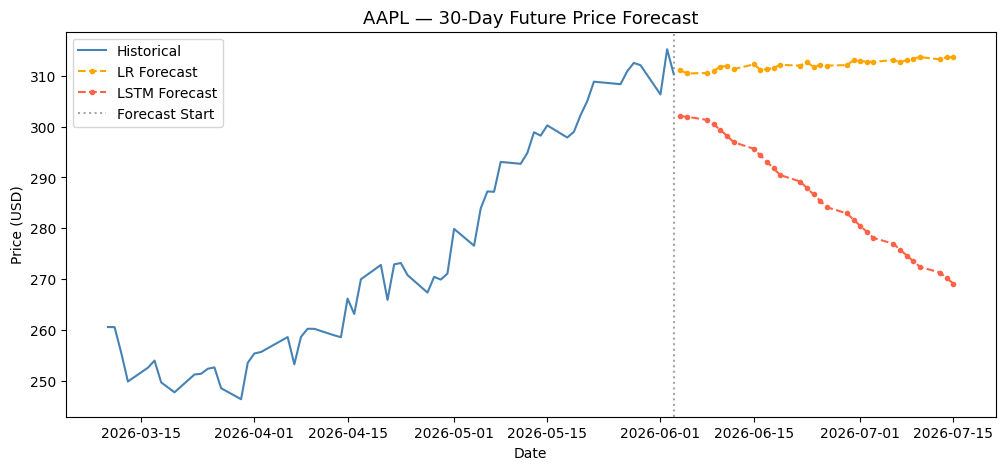

In [29]:
future_dates = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=30, freq='B')

plt.figure(figsize=(12, 5))
plt.plot(df.index[-60:], close[-60:], label='Historical', color='steelblue')
plt.plot(future_dates, lr_future, label='LR Forecast', color='orange', linestyle='--', marker='o', markersize=3)
plt.plot(future_dates, lstm_future, label='LSTM Forecast', color='tomato', linestyle='--', marker='o', markersize=3)
plt.axvline(x=df.index[-1], color='gray', linestyle=':', alpha=0.7, label='Forecast Start')
plt.title(f'{TICKER} — 30-Day Future Price Forecast', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
# ✅ Run this once — fixes ALL savefig paths in the notebook
import os
os.makedirs('/content/screenshots', exist_ok=True)

# Override savefig to always save to /content/screenshots
original_savefig = plt.savefig
def fixed_savefig(path, **kwargs):
    filename = os.path.basename(path)
    original_savefig(f'/content/screenshots/{filename}', **kwargs)
plt.savefig = fixed_savefig

print("✅ savefig fixed! All charts will save to /content/screenshots/")

print(f'\nLast known price:  ${close[-1]:.2f}')
print(f'LR 30-day forecast:   ${lr_future[-1]:.2f}')
print(f'LSTM 30-day forecast: ${lstm_future[-1]:.2f}')

## 7. Metrics Summary Table

In [30]:
# ✅ Metrics Summary Table
summary = pd.DataFrame([
    {"RMSE": rmse,  "MAE": mae,  "R2_Score": r2,   "MAPE": mape},
    {"RMSE": rmse2, "MAE": mae2, "R2_Score": r2_2,  "MAPE": mape2}
], index=['Linear Regression', 'LSTM'])

print(summary.round(4).to_string())

                     RMSE     MAE  R2_Score    MAPE
Linear Regression  3.8306  2.6572    0.9802  1.1358
LSTM               8.9759  7.0548    0.8943  2.9071


In [31]:
import os
files = os.listdir('/content/screenshots')
print("Charts saved:", files)

Charts saved: []
